## Obtención de Coordenadas de Espacios de Estacionamiento

Este notebook utiliza el modelo preentrenado `parking_lot_detector.pth` (Faster R-CNN) para detectar espacios de estacionamiento en una imagen.

In [ ]:
# Instalación de librerías necesarias
!pip install torch torchvision opencv-python

In [152]:
# Imports
import torch
import torch.nn as nn
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from collections import defaultdict

In [153]:
# Verificar GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [154]:
# Cargar el modelo Faster R-CNN preentrenado
def get_model(num_classes):
    """
    Get Faster R-CNN model with ResNet50 backbone
    num_classes incluye background: 1=background, 2=space-empty, 3=space-occupied
    """
    # Cargar modelo pre-entrenado
    model = fasterrcnn_resnet50_fpn(pretrained=False)
    
    # Obtener el número de características de entrada para el clasificador
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Reemplazar la cabeza pre-entrenada con una nueva
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    return model

# Cargar pesos del modelo entrenado
model_path = 'parking_lot_detector.pth'
num_classes = 3  # background + space-empty + space-occupied

model = get_model(num_classes)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

print(f"Modelo cargado: {model_path}")

c:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Modelo cargado: parking_lot_detector.pth


In [155]:
# Ruta de la imagen a procesar
image_path = 'some_test_images/t1.jpg'

# Verificar que la imagen existe
if os.path.exists(image_path):
    print(f"Imagen encontrada: {image_path}")
else:
    print(f"ERROR: Imagen no encontrada en {image_path}")

Imagen encontrada: some_test_images/t1.jpg


In [156]:
# Función de detección
@torch.no_grad()
def detect_parking_spots(model, image, device, threshold=0.5):
    """Detectar espacios de estacionamiento en una imagen"""
    model.eval()

    # Preparar imagen
    img_tensor = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).to(device)
    
    # Inferencia
    predictions = model(img_tensor)[0]
    
    # Filtrar por umbral de confianza
    keep = predictions['scores'] > threshold
    boxes = predictions['boxes'][keep].cpu().numpy()
    labels = predictions['labels'][keep].cpu().numpy()
    scores = predictions['scores'][keep].cpu().numpy()
    
    return boxes, labels, scores

In [157]:
# Agregar padding negro para mantener dimensionalidad 640x640
def add_padding(image, target_size=640):
    """
    Agregar padding negro a la imagen para alcanzar el tamaño objetivo.
    Mantiene la relación aspecto y centra la imagen.
    """
    h, w = image.shape[:2]
    
    # Calcular scale factor para ajustar la imagen dentro del target
    scale = min(target_size / w, target_size / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    
    # Redimensionar la imagen
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    
    # Crear imagen con padding negro del tamaño objetivo
    padded = np.zeros((target_size, target_size, 3), dtype=np.float32)
    
    # Calcular offset para centrar la imagen
    offset_x = (target_size - new_w) // 2
    offset_y = (target_size - new_h) // 2
    
    # Colocar la imagen redimensionada en el centro
    padded[offset_y:offset_y + new_h, offset_x:offset_x + new_w] = resized
    
    return padded, scale, (offset_x, offset_y)

# Función para convertir coordenadas del espacio padded al espacio original
def convert_boxes_to_original(boxes, scale, offset, original_shape):
    """
    Convertir bounding boxes del espacio 640x640 al espacio de la imagen original.
    """
    orig_h, orig_w = original_shape[:2]
    offset_x, offset_y = offset
    
    converted_boxes = []
    
    for box in boxes:
        x1, y1, x2, y2 = box
        
        # Quitar el offset y revertir el scale
        x1_orig = (x1 - offset_x) / scale
        y1_orig = (y1 - offset_y) / scale
        x2_orig = (x2 - offset_x) / scale
        y2_orig = (y2 - offset_y) / scale
        
        # Clip para mantener dentro de los límites de la imagen original
        x1_orig = max(0, min(x1_orig, orig_w))
        y1_orig = max(0, min(y1_orig, orig_h))
        x2_orig = max(0, min(x2_orig, orig_w))
        y2_orig = max(0, min(y2_orig, orig_h))
        
        converted_boxes.append([x1_orig, y1_orig, x2_orig, y2_orig])
    
    return np.array(converted_boxes)

# Cargar imagen original
img_original = cv2.imread(image_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

print(f"Imagen original - Shape: {img_original.shape}")

# Agregar padding
img_padded, scale, offset = add_padding(img_original, target_size=640)

print(f"Imagen con padding - Shape: {img_padded.shape}")
print(f"Scale factor: {scale:.4f}")
print(f"Offset (x, y): {offset}")

Imagen original - Shape: (640, 640, 3)
Imagen con padding - Shape: (640, 640, 3)
Scale factor: 1.0000
Offset (x, y): (0, 0)


In [158]:
# Ejecutar detección con la imagen con padding
threshold = 0.5
boxes_padded, labels, scores = detect_parking_spots(model, img_padded, device, threshold)

print(f"Detecciones en espacio 640x640: {len(boxes_padded)}")

# Convertir coordenadas al espacio de la imagen original
boxes = convert_boxes_to_original(boxes_padded, scale, offset, img_original.shape)

print(f"Detecciones convertidas al espacio original: {len(boxes)}")

Detecciones en espacio 640x640: 100
Detecciones convertidas al espacio original: 100


In [159]:
# Extraer y mostrar las bounding boxes
print("=" * 60)
print("BOUNDING BOXES DE DETECCIÓN DE ESPACIOS DE ESTACIONAMIENTO")
print("=" * 60)

label_names = {
    1: 'space-empty',
    2: 'space-occupied'
}

print(f"\nImagen: {image_path}")
print(f"Número de detecciones: {len(boxes)}")
print("-" * 60)

if len(boxes) > 0:
    for i, (box, label, score) in enumerate(zip(boxes, labels, scores)):
        x1, y1, x2, y2 = box
        
        print(f"Espacio {i + 1}:")
        print(f"  x1: {x1:.2f}")
        print(f"  y1: {y1:.2f}")
        print(f"  x2: {x2:.2f}")
        print(f"  y2: {y2:.2f}")
        print(f"  Tipo: {label_names.get(label, 'Unknown')}")
        print(f"  Confianza: {score:.2%}")
        print("-" * 60)
else:
    print("No se detectaron espacios de estacionamiento en esta imagen.")

BOUNDING BOXES DE DETECCIÓN DE ESPACIOS DE ESTACIONAMIENTO

Imagen: some_test_images/t1.jpg
Número de detecciones: 100
------------------------------------------------------------
Espacio 1:
  x1: 147.97
  y1: 444.19
  x2: 181.84
  y2: 499.98
  Tipo: space-empty
  Confianza: 100.00%
------------------------------------------------------------
Espacio 2:
  x1: 122.82
  y1: 442.01
  x2: 157.57
  y2: 501.48
  Tipo: space-empty
  Confianza: 100.00%
------------------------------------------------------------
Espacio 3:
  x1: 70.51
  y1: 445.56
  x2: 105.86
  y2: 500.76
  Tipo: space-empty
  Confianza: 100.00%
------------------------------------------------------------
Espacio 4:
  x1: 258.74
  y1: 448.17
  x2: 290.64
  y2: 500.69
  Tipo: space-empty
  Confianza: 100.00%
------------------------------------------------------------
Espacio 5:
  x1: 203.82
  y1: 447.96
  x2: 237.43
  y2: 498.29
  Tipo: space-empty
  Confianza: 100.00%
---------------------------------------------------------

In [160]:
# Guardar las coordenadas en variables para uso posterior
bounding_boxes = []

for box, label, score in zip(boxes, labels, scores):
    bounding_boxes.append({
        'x1': float(box[0]),
        'y1': float(box[1]),
        'x2': float(box[2]),
        'y2': float(box[3]),
        'tipo': label_names.get(label, 'Unknown'),
        'confianza': float(score)
    })

print(f"Total de bounding boxes guardadas: {len(bounding_boxes)}")
print("\nLista de bounding boxes:")
for i, bb in enumerate(bounding_boxes):
    print(f"  [{i}] x1={bb['x1']:.2f}, y1={bb['y1']:.2f}, x2={bb['x2']:.2f}, y2={bb['y2']:.2f} | {bb['tipo']} | {bb['confianza']:.2%}")

Total de bounding boxes guardadas: 100

Lista de bounding boxes:
  [0] x1=147.97, y1=444.19, x2=181.84, y2=499.98 | space-empty | 100.00%
  [1] x1=122.82, y1=442.01, x2=157.57, y2=501.48 | space-empty | 100.00%
  [2] x1=70.51, y1=445.56, x2=105.86, y2=500.76 | space-empty | 100.00%
  [3] x1=258.74, y1=448.17, x2=290.64, y2=500.69 | space-empty | 100.00%
  [4] x1=203.82, y1=447.96, x2=237.43, y2=498.29 | space-empty | 100.00%
  [5] x1=230.97, y1=451.03, x2=263.95, y2=504.52 | space-empty | 100.00%
  [6] x1=43.49, y1=444.77, x2=78.80, y2=499.08 | space-empty | 100.00%
  [7] x1=290.01, y1=371.78, x2=313.23, y2=423.69 | space-empty | 99.99%
  [8] x1=166.87, y1=237.87, x2=192.52, y2=275.47 | space-empty | 99.99%
  [9] x1=147.97, y1=374.06, x2=175.01, y2=421.94 | space-occupied | 99.99%
  [10] x1=483.36, y1=227.20, x2=507.41, y2=274.96 | space-empty | 99.99%
  [11] x1=444.17, y1=277.14, x2=467.12, y2=319.46 | space-empty | 99.99%
  [12] x1=267.93, y1=236.00, x2=289.47, y2=272.58 | space-empt

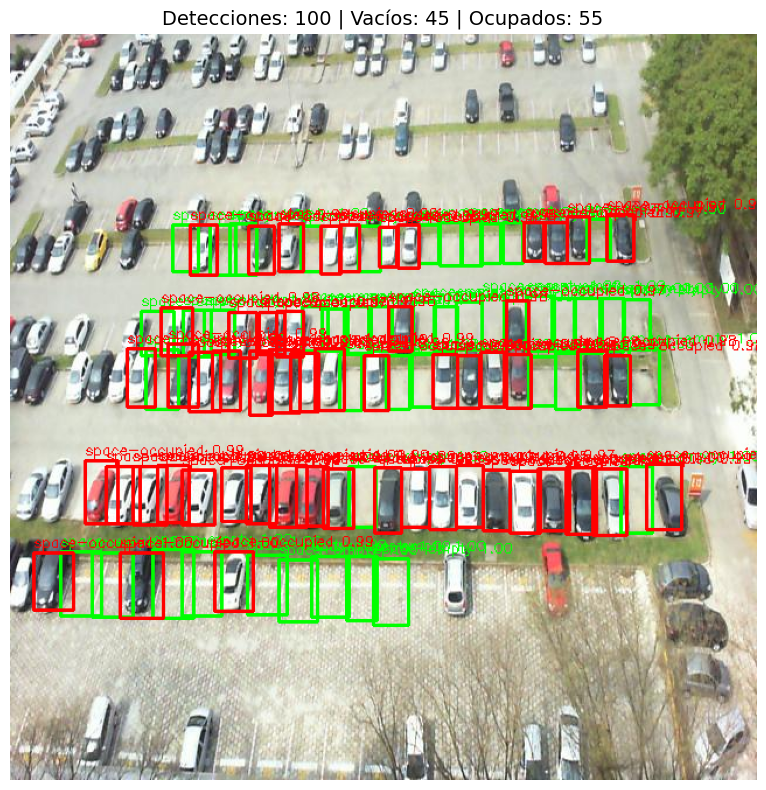


Imagen guardada como: detecciones_visualizadas.png
Total espacios vacíos: 45
Total espacios ocupados: 55


In [161]:
# Visualizar las bounding boxes sobre la imagen original
# Colores para cada tipo de espacio
colors = {
    1: (0, 255, 0),    # Verde para space-empty
    2: (255, 0, 0)     # Rojo para space-occupied
}

# Cargar imagen original para dibujar (sin normalizar)
img_display = cv2.imread(image_path)
img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)

# Dibujar bounding boxes usando coordenadas convertidas
empty_count = 0
occupied_count = 0

for box, label, score in zip(boxes, labels, scores):
    x1, y1, x2, y2 = map(int, box)
    color = colors.get(label, (255, 255, 255))
    
    if label == 1:
        empty_count += 1
    elif label == 2:
        occupied_count += 1
    
    # Dibujar rectángulo
    cv2.rectangle(img_display, (x1, y1), (x2, y2), color, 2)
    
    # Agregar etiqueta con tipo y confianza
    label_text = f"{label_names.get(label, 'Unknown')} {score:.2f}"
    cv2.putText(img_display, label_text, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

# Mostrar imagen con detecciones
plt.figure(figsize=(15, 8))
plt.imshow(img_display)
plt.title(f"Detecciones: {len(boxes)} | Vacíos: {empty_count} | Ocupados: {occupied_count}", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('detecciones_visualizadas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nImagen guardada como: detecciones_visualizadas.png")
print(f"Total espacios vacíos: {empty_count}")
print(f"Total espacios ocupados: {occupied_count}")

Puntos de la región de interés (ROI) en la imagen 640x640:
  Punto 1: [50. 85.]
  Punto 2: [510.  75.]
  Punto 3: [524. 165.]
  Punto 4: [ 20. 175.]


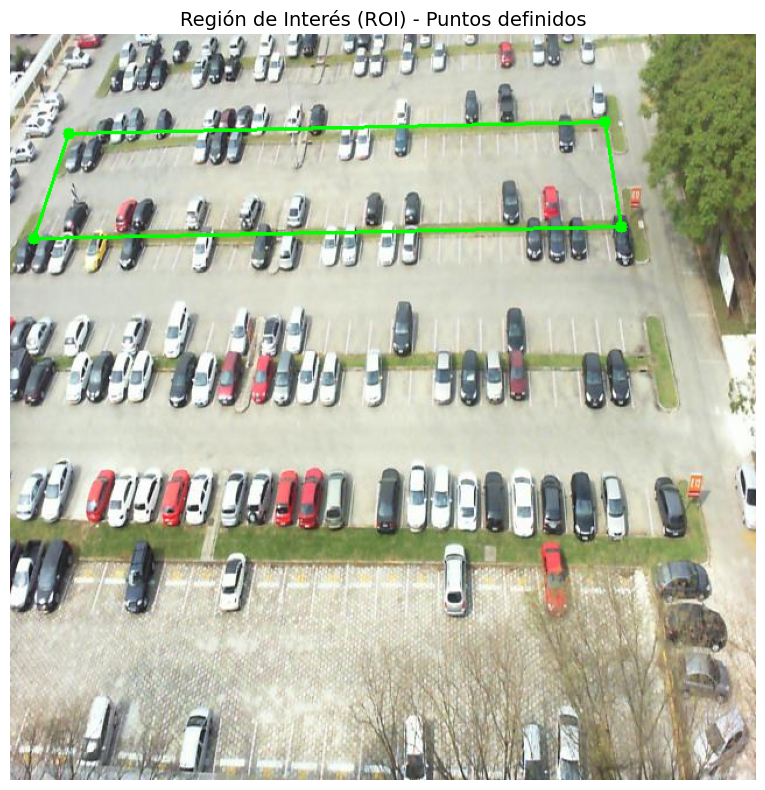


Imagen guardada como: roi_puntos.png


In [ ]:
# =============================================================================
# PIPELINE COMPLETO: Homografía, Padding, Detección y Coordenadas Reales
# =============================================================================

# Definir los 4 puntos de la región de interés (ROI) en la imagen 640x640
# Estos puntos definen un trapecio que será transformado a un rectángulo
roi_points = np.array([
    [50, 85],    # Punto 1: esquina superior izquierda del trapecio
    [510, 75],    # Punto 2: esquina superior derecha del trapecio
    [524, 165],   # Punto 3: esquina inferior derecha del trapecio
    [20, 175]     # Punto 4: esquina inferior izquierda del trapecio
], dtype=np.float32)

print("Puntos de la región de interés (ROI) en la imagen 640x640:")
print(f"  Punto 1: {roi_points[0]}")
print(f"  Punto 2: {roi_points[1]}")
print(f"  Punto 3: {roi_points[2]}")
print(f"  Punto 4: {roi_points[3]}")

# Visualizar los puntos en la imagen original
img_roi_vis = cv2.imread('some_test_images/t1.jpg')
img_roi_vis = cv2.cvtColor(img_roi_vis, cv2.COLOR_BGR2RGB)

# Dibujar los puntos y conectarlos
for point in roi_points:
    cv2.circle(img_roi_vis, (int(point[0]), int(point[1])), 5, (0, 255, 0), -1)

# Conectar los puntos para mostrar el polígono
pts = roi_points.astype(np.int32)
cv2.polylines(img_roi_vis, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

plt.figure(figsize=(12, 8))
plt.imshow(img_roi_vis)
plt.title("Región de Interés (ROI) - Puntos definidos", fontsize=14)
plt.axis('off')
plt.tight_layout()
# plt.savefig('roi_puntos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nImagen guardada como: roi_puntos.png")

In [163]:
# =============================================================================
# Función de Transformación de Perspectiva (Homografía)
# =============================================================================

def perspective_transform_and_pad(image, roi_points, target_size=640):
    """
    1. Aplica transformación de perspectiva para convertir el trapecio en rectángulo
    2. Agrega padding negro para mantener 640x640 manteniendo proporciones
    
    Args:
        image: Imagen de entrada (HxWx3)
        roi_points: 4 puntos del trapecio [top_left, top_right, bottom_right, bottom_left]
        target_size: Tamaño objetivo (default 640)
    
    Returns:
        - Imagen transformada y con padding (target_size x target_size x 3)
        - Matriz de homografía inversa (para convertir coordenadas de vuelta)
        - Scale y offset usados para el padding
    """
    h, w = image.shape[:2]
    
    # Calcular el ancho y alto del rectángulo destino basado en las distancias de los puntos
    # Usamos la distancia entre puntos correspondientes
    
    # Ancho: promedio de las distancias superior e inferior
    top_width = np.linalg.norm(roi_points[1] - roi_points[0])  # distancia top
    bottom_width = np.linalg.norm(roi_points[2] - roi_points[3])  # distancia bottom
    avg_width = (top_width + bottom_width) / 2
    
    # Alto: promedio de las distancias izquierda y derecha
    left_height = np.linalg.norm(roi_points[3] - roi_points[0])  # distancia izquierda
    right_height = np.linalg.norm(roi_points[2] - roi_points[1])  # distancia derecha
    avg_height = (left_height + right_height) / 2
    
    # Calcular el rectángulo destino manteniendo proporciones
    # El ancho y alto deben mantener la relación del rectángulo original
    aspect_ratio = avg_width / avg_height
    
    if aspect_ratio > 1:
        # Más ancho que alto
        dest_width = target_size
        dest_height = int(target_size / aspect_ratio)
    else:
        # Más alto que ancho
        dest_height = target_size
        dest_width = int(target_size * aspect_ratio)
    
    # Asegurar dimensiones mínimas
    dest_width = max(dest_width, 1)
    dest_height = max(dest_height, 1)
    
    print(f"Dimensiones del rectángulo transformado: {dest_width} x {dest_height}")
    print(f"Relación de aspecto: {aspect_ratio:.4f}")
    
    # Definir los puntos destino como un rectángulo
    dst_points = np.array([
        [0, 0],
        [dest_width - 1, 0],
        [dest_width - 1, dest_height - 1],
        [0, dest_height - 1]
    ], dtype=np.float32)
    
    # Calcular la matriz de homografía
    h_matrix = cv2.getPerspectiveTransform(roi_points, dst_points)
    
    # Aplicar la transformación de perspectiva
    warped = cv2.warpPerspective(image, h_matrix, (dest_width, dest_height))
    
    print(f"Imagen transformada - Shape: {warped.shape}")
    
    # Ahora agregar padding para llegar a 640x640
    # Calcular el scale factor para ajustar la imagen dentro del target
    scale = min(target_size / dest_width, target_size / dest_height)
    new_w = int(dest_width * scale)
    new_h = int(dest_height * scale)
    
    # Redimensionar la imagen transformada
    resized = cv2.resize(warped, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    
    # Crear imagen con padding negro del tamaño objetivo
    padded = np.zeros((target_size, target_size, 3), dtype=np.float32)
    
    # Calcular offset para centrar la imagen
    offset_x = (target_size - new_w) // 2
    offset_y = (target_size - new_h) // 2
    
    # Colocar la imagen redimensionada en el centro
    padded[offset_y:offset_y + new_h, offset_x:offset_x + new_w] = resized
    
    # Calcular la matriz de homografía inversa
    # Primero invertimos la transformación de perspectiva, luego el resize y offset
    h_inv = np.linalg.inv(h_matrix)
    
    return padded, h_inv, scale, (offset_x, offset_y), (dest_width, dest_height)

# Cargar imagen completa de 640x640
img_full = cv2.imread('some_test_images/t1.jpg')
img_full = cv2.cvtColor(img_full, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

print(f"Imagen completa - Shape: {img_full.shape}")

# Aplicar transformación de perspectiva y padding
img_transformed, h_inv, scale, offset, dest_size = perspective_transform_and_pad(
    img_full, roi_points, target_size=640
)

print(f"\nImagen final con padding - Shape: {img_transformed.shape}")
print(f"Scale factor para coordenadas: {scale:.4f}")
print(f"Offset (x, y): {offset}")

Imagen completa - Shape: (640, 640, 3)
Dimensiones del rectángulo transformado: 640 x 123
Relación de aspecto: 5.1853
Imagen transformada - Shape: (123, 640, 3)

Imagen final con padding - Shape: (640, 640, 3)
Scale factor para coordenadas: 1.0000
Offset (x, y): (0, 258)


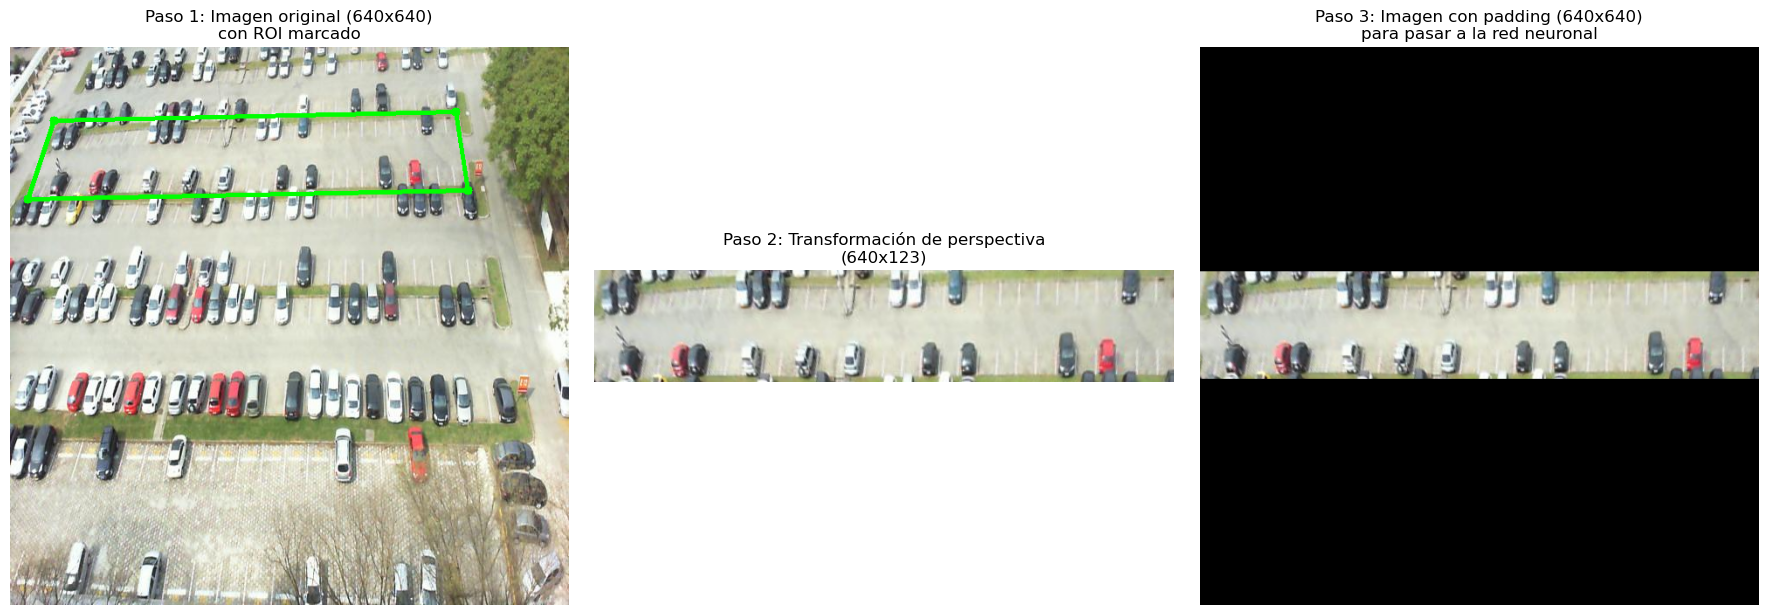


Imagen guardada como: transformaciones_paso_a_paso.png


In [ ]:
# =============================================================================
# Visualización de las Transformaciones
# =============================================================================

# Mostrar las transformaciones en cada paso
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Imagen original con ROI marcado
img_display1 = cv2.imread('some_test_images/t1.jpg')
img_display1 = cv2.cvtColor(img_display1, cv2.COLOR_BGR2RGB)

# Dibujar ROI
for point in roi_points:
    cv2.circle(img_display1, (int(point[0]), int(point[1])), 5, (0, 255, 0), -1)
pts = roi_points.astype(np.int32)
cv2.polylines(img_display1, [pts], isClosed=True, color=(0, 255, 0), thickness=3)

axes[0].imshow(img_display1)
axes[0].set_title("Paso 1: Imagen original (640x640)\ncon ROI marcado", fontsize=12)
axes[0].axis('off')

# Imagen transformada por homografía (antes del padding)
# Recrear la transformación sin padding para visualización
def get_warped_only(image, roi_points, target_size=640):
    h, w = image.shape[:2]
    top_width = np.linalg.norm(roi_points[1] - roi_points[0])
    bottom_width = np.linalg.norm(roi_points[2] - roi_points[3])
    avg_width = (top_width + bottom_width) / 2
    left_height = np.linalg.norm(roi_points[3] - roi_points[0])
    right_height = np.linalg.norm(roi_points[2] - roi_points[1])
    avg_height = (left_height + right_height) / 2
    aspect_ratio = avg_width / avg_height
    
    if aspect_ratio > 1:
        dest_width = target_size
        dest_height = int(target_size / aspect_ratio)
    else:
        dest_height = target_size
        dest_width = int(target_size * aspect_ratio)
    
    dest_width = max(dest_width, 1)
    dest_height = max(dest_height, 1)
    
    dst_points = np.array([
        [0, 0],
        [dest_width - 1, 0],
        [dest_width - 1, dest_height - 1],
        [0, dest_height - 1]
    ], dtype=np.float32)
    
    h_matrix = cv2.getPerspectiveTransform(roi_points, dst_points)
    warped = cv2.warpPerspective(image, h_matrix, (dest_width, dest_height))
    
    return warped, h_matrix

img_warped_only, h_matrix = get_warped_only(img_full, roi_points)
img_warped_vis = (img_warped_only * 255).astype(np.uint8)

axes[1].imshow(img_warped_vis)
axes[1].set_title(f"Paso 2: Transformación de perspectiva\n({img_warped_only.shape[1]}x{img_warped_only.shape[0]})", fontsize=12)
axes[1].axis('off')

# Imagen final con padding
img_padded_vis = (img_transformed * 255).astype(np.uint8)
axes[2].imshow(img_padded_vis)
axes[2].set_title("Paso 3: Imagen con padding (640x640)\npara pasar a la red neuronal", fontsize=12)
axes[2].axis('off')

plt.tight_layout()
#plt.savefig('transformaciones_paso_a_paso.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nImagen guardada como: transformaciones_paso_a_paso.png")

In [165]:
# =============================================================================
# Conversión a Coordenadas Reales (metros) - Solo espacios ocupados
# =============================================================================

# El espacio real es de 76m de ancho por 13.5m de alto
# Este espacio corresponde al ROI transformado, no a la imagen completa
REAL_WIDTH = 76.0   # metros
REAL_HEIGHT = 13.5  # metros

# El tamaño del ROI transformado (sin padding)
dest_w, dest_h = dest_size

print(f"Dimensiones del ROI transformado: {dest_w} x {dest_h}")
print(f"Espacio real: {REAL_WIDTH}m x {REAL_HEIGHT}m")

# Factor de conversión: pixels (del ROI) a metros
PIXEL_TO_METER_X = REAL_WIDTH / dest_w
PIXEL_TO_METER_Y = REAL_HEIGHT / dest_h

print(f"Factor de conversión X: {PIXEL_TO_METER_X:.4f} m/pixel")
print(f"Factor de conversión Y: {PIXEL_TO_METER_Y:.4f} m/pixel")

# Filtrar solo los espacios ocupados (label == 2)
print("\n" + "=" * 60)
print("FILTRANDO SOLO ESPACIOS OCUPADOS (CON VEHÍCULOS)")
print("=" * 60)

occupied_boxes = []
occupied_labels = []
occupied_scores = []
occupied_centers = []
occupied_coords_real = []

for box, label, score, center in zip(boxes, labels, scores, centers):
    if label == 2:  # Solo space-occupied
        cx, cy = center
        
        # Convertir al espacio del ROI (antes del padding)
        # Invertir la transformación de padding
        offset_x, offset_y = offset
        cx_roi = (cx - offset_x) / scale
        cy_roi = (cy - offset_y) / scale
        
        # Escalar al tamaño del ROI transformado
        cx_roi = cx_roi * (dest_w / 640)
        cy_roi = cy_roi * (dest_h / 640)
        
        # Convertir a coordenadas reales (metros)
        x_meters = cx_roi * PIXEL_TO_METER_X
        y_meters = cy_roi * PIXEL_TO_METER_Y
        
        occupied_boxes.append(box)
        occupied_labels.append(label)
        occupied_scores.append(score)
        occupied_centers.append(center)
        occupied_coords_real.append((x_meters, y_meters))
        
        print(f"Vehículo detectado:")
        print(f"  Centro en imagen: ({cx:.2f}, {cy:.2f})")
        print(f"  Centro en ROI: ({cx_roi:.2f}, {cy_roi:.2f})")
        print(f"  Coordenada real: X = {x_meters:.4f}m, Y = {y_meters:.4f}m")
        print(f"  Confianza: {score:.2%}")
        print("-" * 40)

# Guardar como lista de tuplas (X, Y) en metros
coordinates_xy_occupied = [(round(x, 4), round(y, 4)) for x, y in occupied_coords_real]

print(f"\nTotal de vehículos detectados: {len(occupied_coords_real)}")
print(f"\nLista de coordenadas (X, Y) en metros - Solo ocupados:")
print(coordinates_xy_occupied)

Dimensiones del ROI transformado: 640 x 123
Espacio real: 76.0m x 13.5m
Factor de conversión X: 0.1187 m/pixel
Factor de conversión Y: 0.1098 m/pixel

FILTRANDO SOLO ESPACIOS OCUPADOS (CON VEHÍCULOS)
Vehículo detectado:
  Centro en imagen: (394.61, 79.88)
  Centro en ROI: (394.61, -34.23)
  Coordenada real: X = 46.8601m, Y = -3.7573m
  Confianza: 99.99%
----------------------------------------
Vehículo detectado:
  Centro en imagen: (289.42, 82.67)
  Centro en ROI: (289.42, -33.70)
  Coordenada real: X = 34.3692m, Y = -3.6984m
  Confianza: 99.92%
----------------------------------------
Vehículo detectado:
  Centro en imagen: (248.39, 93.57)
  Centro en ROI: (248.39, -31.60)
  Coordenada real: X = 29.4962m, Y = -3.4683m
  Confianza: 99.89%
----------------------------------------

Total de vehículos detectados: 3

Lista de coordenadas (X, Y) en metros - Solo ocupados:
[(np.float64(46.8601), np.float64(-3.7573)), (np.float64(34.3692), np.float64(-3.6984)), (np.float64(29.4962), np.float

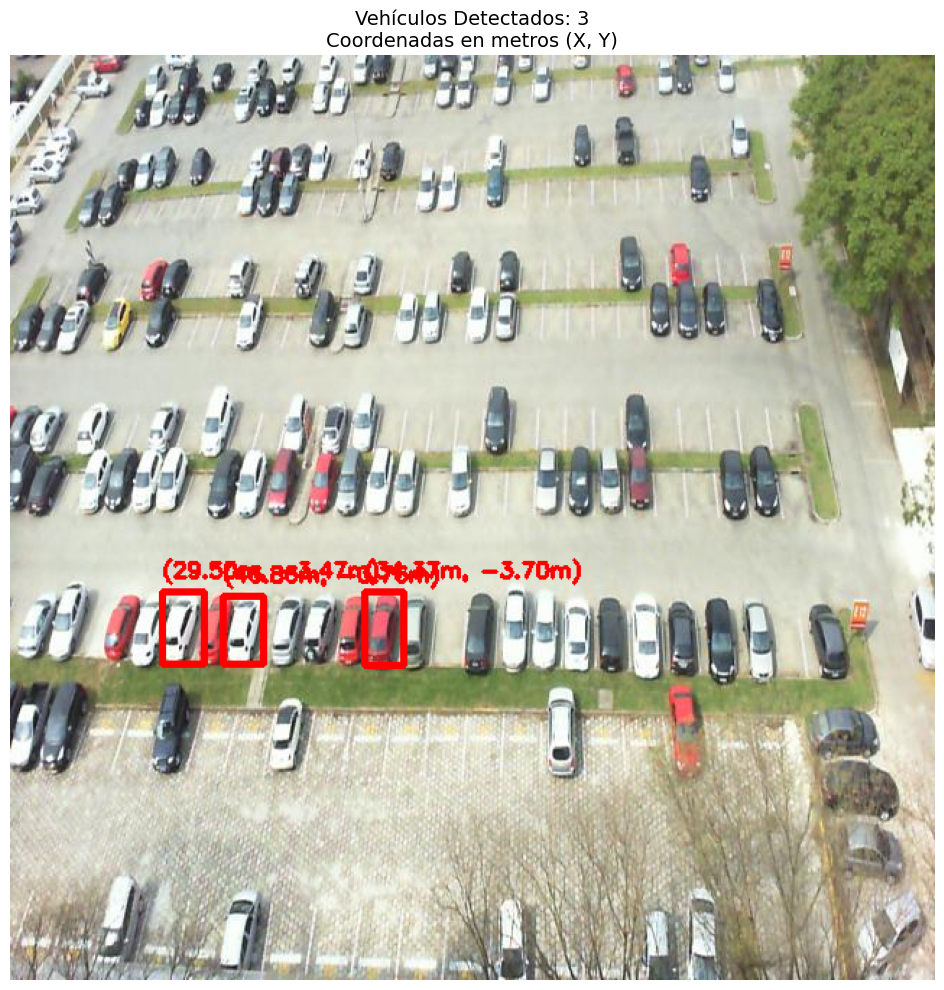


Imagen guardada como: vehiculos_detectados.png
Total de vehículos detectados: 3

Coordenadas finales (lista de tuplas):
[(np.float64(46.8601), np.float64(-3.7573)), (np.float64(34.3692), np.float64(-3.6984)), (np.float64(29.4962), np.float64(-3.4683))]


In [166]:
# =============================================================================
# Visualización Final: Solo vehículos detectados (espacios ocupados)
# =============================================================================

# Colores para cada tipo de espacio
colors = {
    1: (0, 255, 0),    # Verde para space-empty
    2: (255, 0, 0)     # Rojo para space-occupied
}

label_names = {
    1: 'space-empty',
    2: 'space-occupied'
}

# Cargar imagen original para dibujar
img_display_final = cv2.imread('some_test_images/t1.jpg')
img_display_final = cv2.cvtColor(img_display_final, cv2.COLOR_BGR2RGB)

# Dibujar solo los bounding boxes de vehículos ocupados
for box, label, score, center, coord_real in zip(
    occupied_boxes, occupied_labels, occupied_scores, 
    occupied_centers, occupied_coords_real
):
    x1, y1, x2, y2 = map(int, box)
    color = colors.get(label, (255, 255, 255))
    
    # Dibujar rectángulo
    cv2.rectangle(img_display_final, (x1, y1), (x2, y2), color, 3)
    
    # Agregar etiqueta con coordenada real
    x_real, y_real = coord_real
    label_text = f"({x_real:.2f}m, {y_real:.2f}m)"
    cv2.putText(img_display_final, label_text, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

# Mostrar imagen con detecciones
plt.figure(figsize=(15, 10))
plt.imshow(img_display_final)
plt.title(f"Vehículos Detectados: {len(occupied_boxes)}\nCoordenadas en metros (X, Y)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('vehiculos_detectados.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nImagen guardada como: vehiculos_detectados.png")
print(f"Total de vehículos detectados: {len(occupied_coords_real)}")
print(f"\nCoordenadas finales (lista de tuplas):")
print(coordinates_xy_occupied)